In [5]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
import yfinance as yf
import matplotlib.pyplot as plt

In [6]:
import os
os.chdir('C:/Users/basleal/Desktop/tutorial/kaim-week-11')

In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
ticker = ['TSLA','BND','SPY']
starttime = '2015-01-01'
endtime = '2025-01-31'
data = yf.download(ticker,start=starttime,end=endtime)

[*********************100%***********************]  3 of 3 completed


Now we preprocess our data for our model

In [53]:
split_ratio=0.8
split_index = int(len(data)*split_ratio)
    #train_test
train = data.iloc[:split_index]
test = data.iloc[split_index:]

In [10]:
train.tail()

Price           Close                               High              \
Ticker            BND         SPY        TSLA        BND         SPY   
Date                                                                   
2023-01-17  68.601524  386.852692  131.490005  68.722250  389.245195   
2023-01-18  69.233040  380.744995  128.779999  69.335195  389.138137   
2023-01-19  69.093712  377.973267  127.169998  69.158719  380.346270   
2023-01-20  68.787277  385.014557  133.419998  68.898721  385.170169   
2023-01-23  68.620087  389.634155  143.750000  68.777960  391.598703   

Price                         Low                               Open  \
Ticker            TSLA        BND         SPY        TSLA        BND   
Date                                                                   
2023-01-17  131.699997  68.480792  386.162187  125.019997  68.499369   
2023-01-18  136.679993  68.982292  380.540767  127.010002  69.279470   
2023-01-19  129.990005  68.963697  376.631138  124.309998  69.056564   
2023-01-20  133.509995  68.657263  377.720404  127.349998  68.842996   
2023-01-23  145.380005  68.582939  384.858914  134.270004  68.610798   

Price                                Volume                       
Ticker             SPY        TSLA      BND       SPY       TSLA  
Date                                                              
2023-01-17  387.543226  125.699997  6815100  62677300  186477000  
2023-01-18  388.058617  136.559998  5112800  99632300  195680300  
2023-01-19  378.673477  127.260002  4765200  86958900  170291900  
2023-01-20  379.393198  128.679993  4714300  91806400  138858100  
2023-01-23  385.831467  135.869995  6116700  84178800  203119200

In [54]:
train.columns=['_'.join(col) for col in train.columns]#flatten multiIndex
train.columns
test.columns=['_'.join(col) for col in test.columns]#flatten multiIndex using join

In [55]:
test.columns


Index(['Close_BND', 'Close_SPY', 'Close_TSLA', 'High_BND', 'High_SPY',
       'High_TSLA', 'Low_BND', 'Low_SPY', 'Low_TSLA', 'Open_BND', 'Open_SPY',
       'Open_TSLA', 'Volume_BND', 'Volume_SPY', 'Volume_TSLA'],
      dtype='object')

In [13]:
lstm_model = load_model('lstm.keras')
lstm_model.summary()

c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 1, 50)          │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1, 50)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,804 (249.24 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 31,903 (124.62 KB)

In [14]:
test_ticker_bnd=test['Close_BND'].squeeze()
train_ticker_bnd = train['Close_BND'].squeeze()
print(test_ticker_bnd.index)

DatetimeIndex(['2023-01-24', '2023-01-25', '2023-01-26', '2023-01-27',
               '2023-01-30', '2023-01-31', '2023-02-01', '2023-02-02',
               '2023-02-03', '2023-02-06',
               ...
               '2025-01-16', '2025-01-17', '2025-01-21', '2025-01-22',
               '2025-01-23', '2025-01-24', '2025-01-27', '2025-01-28',
               '2025-01-29', '2025-01-30'],
              dtype='datetime64[ns]', name='Date', length=507, freq=None)


Now we forecast for our datas on bnd and spy

In [16]:
X_bnd_train = train['Close_BND'].values.reshape(-1, 1)  # Ensure it's 2D
y_bnd_train = train['Close_BND'].values  # Target variable

X_bnd_test = test['Close_BND'].values.reshape(-1,1)
y_bnd_test = test['Close_BND'].values
X_spy_train = train['Close_SPY'].values.reshape(-1, 1)  # Ensure it's 2D
y_spy_train = train['Close_SPY'].values  # Target variable

X_spy_test = test['Close_SPY'].values.reshape(-1,1)
y_spy_test = test['Close_SPY'].values

In [19]:
y_bnd_train

array([62.38708496, 62.56823349, 62.74935532, ..., 69.09371185,
       68.78727722, 68.62008667])

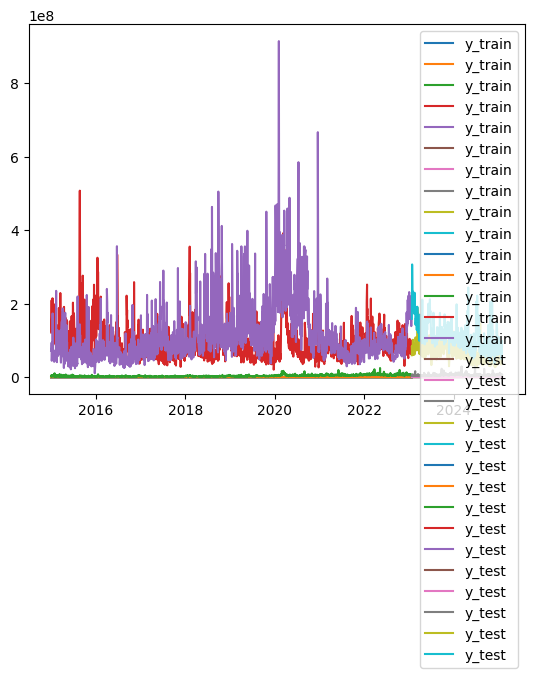

In [71]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train, label='y_train')  # Fixed
plt.plot(test, label='y_test')    # Fixed
plt.legend()
plt.show()

In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

# Fit and transform X
X_train_bnd_scaled = scaler.fit_transform(X_bnd_train)
X_test_bnd_scaled = scaler.transform(X_bnd_test)

X_train_bnd_scaled = X_train_bnd_scaled.reshape((X_train_bnd_scaled.shape[0], 1, X_train_bnd_scaled.shape[1]))  
X_test_bnd_scaled = X_test_bnd_scaled.reshape((X_test_bnd_scaled.shape[0], 1, X_test_bnd_scaled.shape[1]))  

# Fit and transform y separately
y_train_bnd_scaled = scaler.fit_transform(y_bnd_train.reshape(-1, 1))
y_test_bnd_scaled = scaler.transform(y_bnd_test.reshape(-1, 1))

In [21]:
# Separate scalers for X and y
scaler = MinMaxScaler(feature_range=(0,1))
# Fit and transform X
X_train_spy_scaled = scaler.fit_transform(X_spy_train)
X_test_spy_scaled = scaler.transform(X_spy_test)

X_train_spy_scaled = X_train_spy_scaled.reshape((X_train_spy_scaled.shape[0], 1, X_train_spy_scaled.shape[1]))  
X_test_spy_scaled = X_test_spy_scaled.reshape((X_test_spy_scaled.shape[0], 1, X_test_spy_scaled.shape[1]))  

# Fit and transform y separately
y_train_spy_scaled = scaler.fit_transform(y_spy_train.reshape(-1, 1))
y_test_spy_scaled = scaler.transform(y_spy_test.reshape(-1, 1))

Forecast next for bnd

Train for BND

In [22]:
from scripts.model_prep import lstm_model
lstm_modell_bnd=lstm_model(X_train_bnd_scaled,y_train_bnd_scaled,X_test_bnd_scaled,y_test_bnd_scaled)

c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.1645 - val_loss: 0.0082
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0345 - val_loss: 0.0016
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0047 - val_loss: 3.5555e-04
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0039 - val_loss: 1.7294e-04
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0046 - val_loss: 1.5242e-04
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0038 - val_loss: 2.3921e-04
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0038 - val_loss: 4.7235e-05
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0039 - val_loss: 5.9518e-04
Epoch 9/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0037 - val_loss: 4.4464e-06
Epoch 10/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0041 - val_loss: 1.4501e-04
Epoch 11/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0034 - val_loss: 2.9535e-06
Epoch 12/20
64/64 ━━━━━━━━━━━━━━━━━━━

In [23]:
from sklearn.metrics import mean_absolute_error

In [29]:
bnd_forecast = lstm_modell_bnd.predict(X_test_bnd_scaled)

predicted_bnd = scaler.inverse_transform(bnd_forecast)
y_test_bnd_orig = scaler.inverse_transform(y_test_bnd_scaled)
#print(predicted_bnd)
mae = mean_absolute_error(predicted_bnd,y_test_bnd_orig)
print('mae:' , mae)


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
mae: 2.671212907820559


In [30]:
#predicted_actual = pd.Series(predicted_actual.flatten(), index=test_ticker_tsla.index)
y_bnd_test_series=pd.Series(y_test_bnd_orig.flatten(),index=test_ticker_bnd.index)
y_bnd_train_series=pd.Series(y_bnd_train.flatten(),index=train_ticker_bnd.index)
predicted_bnd_series = pd.Series(predicted_bnd[:, 0], index=test_ticker_bnd.index)

print(y_bnd_train_series)


Date
2015-01-02    62.387085
2015-01-05    62.568233
2015-01-06    62.749355
2015-01-07    62.787151
2015-01-08    62.689011
                ...    
2023-01-17    68.601524
2023-01-18    69.233040
2023-01-19    69.093712
2023-01-20    68.787277
2023-01-23    68.620087
Length: 2028, dtype: float64


now we train our spy data on our model

In [36]:
lstm_modell_spy=lstm_model(X_train_spy_scaled,y_train_spy_scaled,X_test_spy_scaled,y_test_spy_scaled)

c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - loss: 0.1469 - val_loss: 0.2693
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0298 - val_loss: 0.0195
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0037 - val_loss: 0.0054
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0033 - val_loss: 0.0029
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0034 - val_loss: 0.0058
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0034 - val_loss: 0.0034
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0033 - val_loss: 0.0019
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0028 - val_loss: 0.0013
Epoch 9/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0030 - val_loss: 5.2971e-04
Epoch 10/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0026 - val_loss: 4.4973e-04
Epoch 11/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0029 - val_loss: 1.1162e-04
Epoch 12/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss:

now let's predict the spy future datas

In [38]:
spy_forecast = lstm_modell_spy.predict(X_test_spy_scaled)
predicted_spy = scaler.inverse_transform(spy_forecast)
predicted_spy

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


array([[388.10535],
       [388.24316],
       [392.27936],
       [393.13077],
       [388.4637 ],
       [393.8627 ],
       [397.80707],
       [403.24542],
       [399.21912],
       [396.92255],
       [401.80194],
       [397.67035],
       [394.42038],
       [395.28857],
       [399.65594],
       [399.4831 ],
       [400.70224],
       [395.50772],
       [394.5758 ],
       [387.08493],
       [386.57895],
       [388.528  ],
       [384.59006],
       [385.8335 ],
       [384.47943],
       [383.07767],
       [385.90717],
       [391.76648],
       [392.02298],
       [386.33054],
       [386.92856],
       [380.14014],
       [374.90414],
       [374.39334],
       [380.2974 ],
       [378.02982],
       [384.34116],
       [380.0647 ],
       [383.54153],
       [388.31894],
       [382.03146],
       [383.01364],
       [385.40112],
       [386.08502],
       [385.26242],
       [390.5673 ],
       [392.72867],
       [397.94604],
       [399.37244],
       [397.28717],


In [39]:
y_test_spy_orig = scaler.inverse_transform(y_test_spy_scaled)
mae_spy=mean_absolute_error(y_test_spy_orig, predicted_spy)
print('mae of our spy prediction is:',mae_spy)

mae of our spy prediction is: 12.111365384133846


In [40]:
y_test_spy_orig = scaler.inverse_transform(y_test_spy_scaled)
predicted_spy_series = pd.Series(predicted_spy[:, 0], index=test_ticker_bnd.index)
y_spy_train_series=pd.Series(y_spy_train.flatten(),index=train_ticker_bnd.index)
y_spy_test_series=pd.Series(y_test_spy_orig.flatten(),index=test_ticker_bnd.index)

In [61]:
print(y_bnd_test)
print(predicted_bnd)

[68.92655182 69.01014709 68.88013458 68.80580902 68.61081696 68.92655182
 69.36965942 69.41619873 68.80180359 68.37361145 68.28053284 68.40154266
 68.12228394 67.83370972 68.0198822  67.78716278 67.63821411 67.37757111
 67.52648926 66.94006348 67.08898926 67.33102417 66.9586792  67.07035828
 67.08898926 66.69152069 66.55157471 67.06475067 66.9061203  66.8314743
 66.77548981 66.99940491 67.80181885 68.34295654 67.91374969 68.61351013
 68.28697205 68.78145599 68.48292542 68.29631042 68.90276337 69.06134796
 69.20133209 68.48292542 68.36160278 68.43625641 68.52955627 68.8841095
 69.17686462 69.45746613 69.64452362 69.62582397 69.15815735 69.18621063
 69.2610321  69.22362518 68.91497803 68.54084778 68.64373779 68.55018616
 68.84949493 68.72789764 68.99913788 69.44810486 69.20491791 68.9056015
 69.28910828 68.5765152  69.25159454 69.54223633 69.44847107 69.19533539
 68.86717224 68.79216766 69.21408844 69.4391098  69.07344055 68.89530182
 68.72653961 68.60463715 68.32336426 68.13583374 68.11

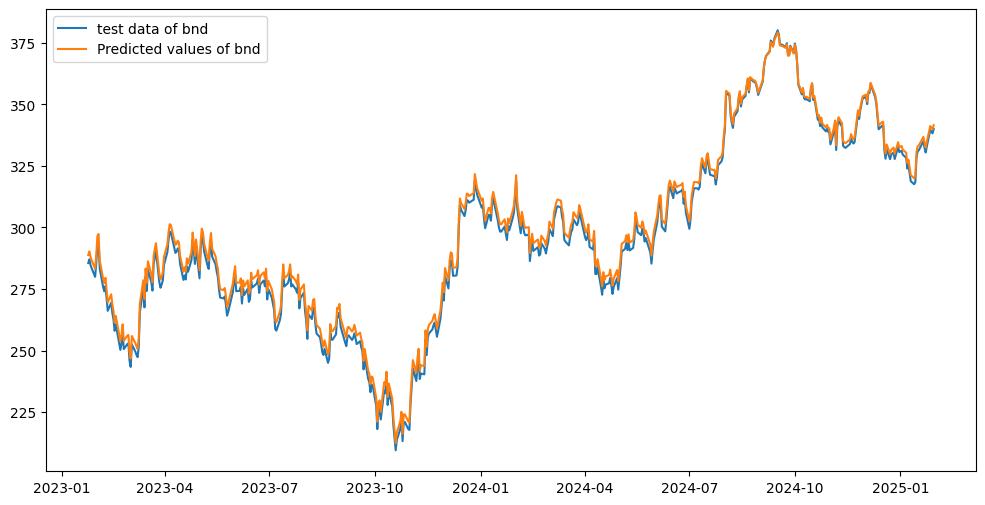

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(y_bnd_test_series, label='test data of bnd')
plt.plot(predicted_bnd_series, label='Predicted values of bnd')
plt.legend()
plt.show()

Now let's plot the graph of the spy model prediction

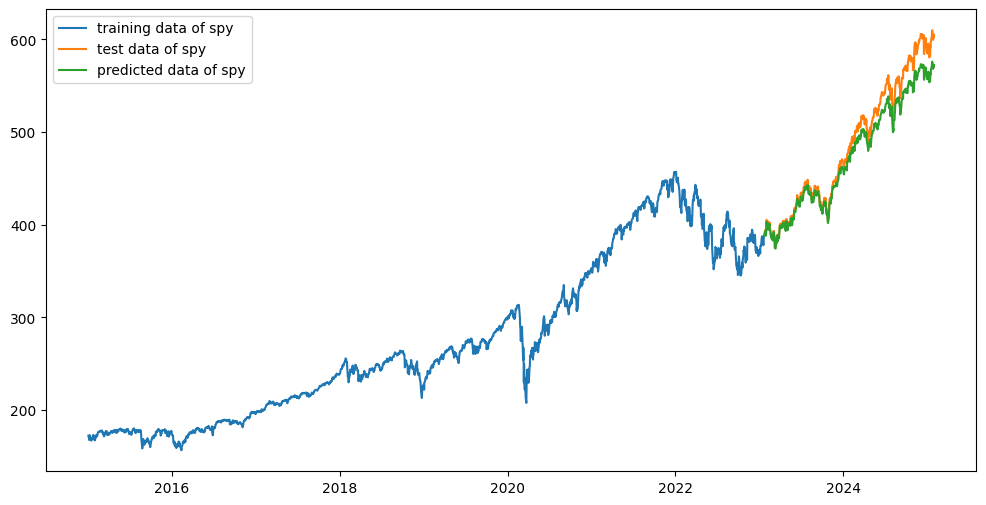

In [43]:
plt.figure(figsize=(12,6))
plt.plot(y_spy_train_series,label='training data of spy')
plt.plot(y_spy_test_series,label='test data of spy')
plt.plot(predicted_spy_series,label='predicted data of spy')
plt.legend()
plt.show()

now let's predictions for the next 6 months

first let's scale our data(training and test)

In [63]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

bnd_scaler = MinMaxScaler(feature_range=(0,1))
bnd_scaler.fit(train[['Close_BND']])  # Fit the scaler to the training data



MinMaxScaler()

In [ ]:
import numpy as np

# Get last 30 days of TSLA prices (from test or full dataset)
last_30_days = y_bnd_test[-30:].reshape(-1, 1)  

# Scale the input using the same scaler
last_30_days_scaled = bnd_scaler.transform(last_30_days)

# Reshape for LSTM input (samples, timesteps, features)
last_30_days_scaled = last_30_days_scaled.reshape(1, 30, 1)  

# Predict next 6 months (let's assume 126 trading days)
future_predictions = []
input_seq = last_30_days_scaled.copy()

for _ in range(126):  # Predict recursively
    predicted_scaled = lstm_modell_bnd.predict(input_seq)
    future_predictions.append(predicted_scaled[0, 0])  # Store the prediction
    
    # Update input sequence (drop first, append latest)
    input_seq = np.roll(input_seq, -1, axis=1)
    input_seq[0, -1, 0] = predicted_scaled

# Convert predictions back to original scale
future_predictions = np.array(future_predictions).reshape(-1, 1)
future_predictions_original_bnd = bnd_scaler.inverse_transform(future_predictions)

# Print or visualize results
print(future_predictions_original_bnd)

c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


C:\Users\basleal\AppData\Local\Temp\ipykernel_10068\4248076266.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  input_seq[0, -1, 0] = predicted_scaled


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1

In [79]:
print(future_predictions_original_bnd)

[[146.71237 ]
 [125.43709 ]
 [120.24008 ]
 [116.68243 ]
 [114.59943 ]
 [113.28856 ]
 [112.42536 ]
 [111.82969 ]
 [111.39915 ]
 [111.077484]
 [110.832275]
 [110.64216 ]
 [110.493126]
 [110.37516 ]
 [110.281235]
 [110.20625 ]
 [110.14653 ]
 [110.09927 ]
 [110.06229 ]
 [110.027054]
 [109.983345]
 [109.93771 ]
 [109.89307 ]
 [109.851074]
 [109.811714]
 [109.775314]
 [109.74171 ]
 [109.71271 ]
 [109.68724 ]
 [109.66574 ]
 [109.649864]
 [110.038376]
 [110.07205 ]
 [110.07913 ]
 [110.06968 ]
 [110.05802 ]
 [110.04661 ]
 [110.03753 ]
 [110.03062 ]
 [110.019966]
 [110.01416 ]
 [110.010185]
 [110.0074  ]
 [110.00523 ]
 [110.00344 ]
 [110.00188 ]
 [110.00047 ]
 [109.9993  ]
 [109.99794 ]
 [109.99692 ]
 [109.99611 ]
 [109.99536 ]
 [109.99469 ]
 [109.994095]
 [109.99353 ]
 [109.99308 ]
 [109.99275 ]
 [109.99257 ]
 [109.99246 ]
 [109.9924  ]
 [109.99249 ]
 [109.99258 ]
 [109.99408 ]
 [109.994865]
 [109.995346]
 [109.99559 ]
 [109.99568 ]
 [109.99571 ]
 [109.99569 ]
 [109.99566 ]
 [109.995605]
 [109.

now let's plot the future forcast

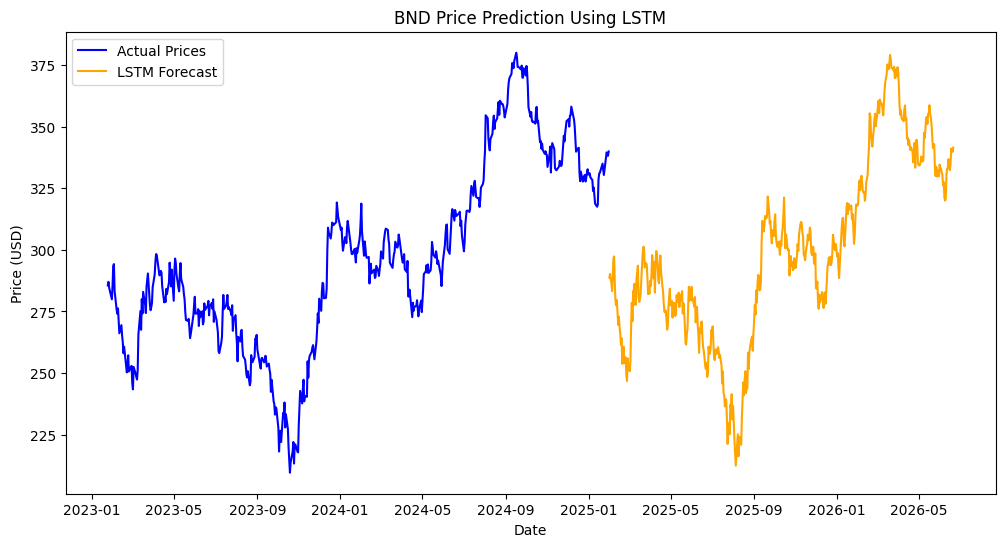

In [81]:
# Create dates for plotting (assuming you have a 'dates_test' list)
dates_test = test.index  # Get the actual test data dates
future_dates = pd.date_range(start=dates_test[-1], periods=len(predicted_bnd) + 1, freq='D')[1:]

# Plot actual vs. predicted prices
plt.figure(figsize=(12,6))
plt.plot(dates_test, y_bnd_test_series, label="Actual Prices", color='blue', linestyle='solid')
plt.plot(future_dates, predicted_bnd, label="LSTM Forecast", color='orange', linestyle='solid')

# Add title and labels
plt.title("BND Price Prediction Using LSTM")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

now we also plot for spy ticker

In [74]:
spy_scaler = MinMaxScaler(feature_range=(0,1))
spy_scaler.fit(train[['Close_SPY']])  # Fit the scaler to the training data

MinMaxScaler()

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Predict the next 6 months for SPY
last_30_days = test['Close_SPY'].values[-30:].reshape(-1, 1)  

# Scale the input using the same scaler
last_30_days_scaled = spy_scaler.transform(last_30_days)

# Reshape for LSTM input (samples, timesteps, features)
last_30_days_scaled = last_30_days_scaled.reshape(1, 30, 1)  

# Predict next 6 months (126 trading days)
future_predictions_spy = []
input_seq = last_30_days_scaled.copy()

for _ in range(126):  # Predict recursively
    predicted_scaled = lstm_modell_spy.predict(input_seq)
    future_predictions_spy.append(predicted_scaled[0, 0])  # Store the prediction
    
    # Update input sequence (drop first, append latest)
    input_seq = np.roll(input_seq, -1, axis=1)
    input_seq[0, -1, 0] = predicted_scaled

# Convert predictions back to original scale
future_predictions_spy = np.array(future_predictions_spy).reshape(-1, 1)
future_predictions_original_spy = spy_scaler.inverse_transform(future_predictions_spy)

# Generate future dates for the forecast
future_dates = pd.date_range(start=test.index[-1], periods=len(future_predictions_original_spy) + 1, freq='D')[1:]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

c:\Users\basleal\Desktop\tutorial\kaim-week-11\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


C:\Users\basleal\AppData\Local\Temp\ipykernel_10068\1463142625.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  input_seq[0, -1, 0] = predicted_scaled


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/ste

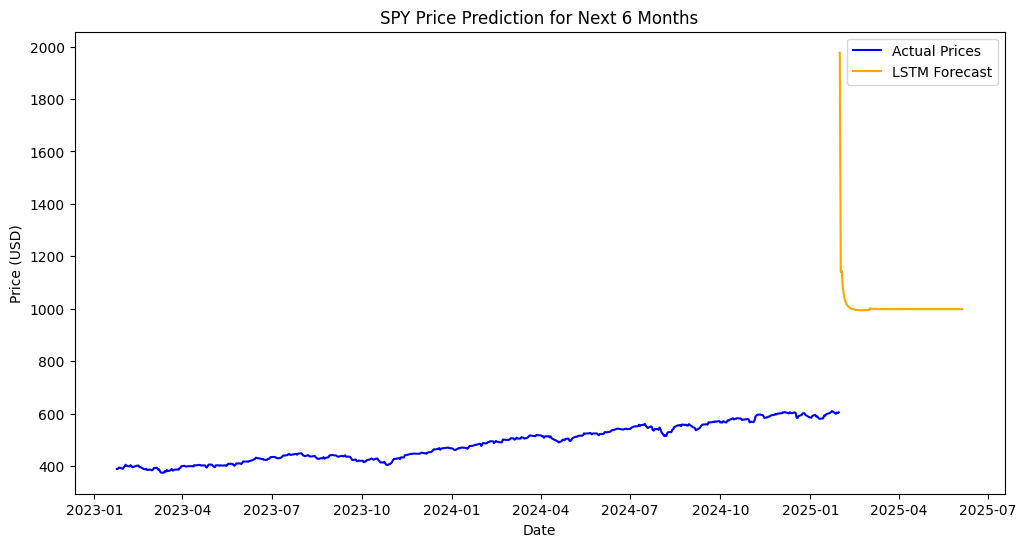

In [92]:
# Plot actual vs. forecasted SPY prices
plt.figure(figsize=(12,6))
plt.plot(test.index, test['Close_SPY'], label="Actual Prices", color='blue', linestyle='solid')
plt.plot(future_dates, future_predictions_original_spy, label="LSTM Forecast", color='orange', linestyle='solid')

# Add title and labels
plt.title("SPY Price Prediction for Next 6 Months")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()